# Benchmarking Multiple Epigenetic Aging Clocks on Two Biolearn Datasets


This notebook benchmarks multiple DNA methylation–based biomarkers of aging using the Biolearn framework on two complete datasets with chronological age metadata. Eight aging clocks are compared to examine their correlation structure, deviation patterns across samples, and age-prediction performance. The analysis includes visualizations and quantitative metrics such as MAE, RMSE, and Pearson correlation to assess how consistently these clocks perform across datasets.


## 1. Install and Import Required Libraries

In [ ]:
!pip install -q biolearn

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from biolearn.data_library import DataLibrary
from biolearn.model_gallery import ModelGallery
from biolearn.visualize import (
    plot_clock_correlation_matrix,
    plot_clock_deviation_heatmap,
    plot_age_prediction
)

print("Biolearn environment ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 7.1 MB/s eta 0:00:00
Biolearn environment ready.


**Explanation**

* This block installs and imports the **Biolearn package** along with standard Python libraries for **data handling**, **numerical analysis**, and **plotting**.
* `DataLibrary` is used to access curated methylation datasets, while `ModelGallery` provides prebuilt aging clock models available in Biolearn.
* The visualization utilities are imported to generate the three required comparison plots: **correlation matrix**, **deviation heatmap**, and **prediction vs age plots**.

## 2. Load Two Complete Biolearn Datasets

In [ ]:
# --------------------------------------------------
# Load two complete methylation datasets from Biolearn
# --------------------------------------------------
dataset_ids = ["GSE120307", "GSE41169"]
library = DataLibrary()

datasets = {}
dataset_descriptions = {
    "GSE120307": "Blood DNA methylation dataset with complete chronological age metadata for all samples. It is also commonly used in Biolearn examples.",
    "GSE41169": "Blood DNA methylation dataset from a Dutch population study with 95 samples and complete chronological age metadata."
}

for ds_id in dataset_ids:
    print(f"Loading {ds_id} ...")
    datasets[ds_id] = library.get(ds_id).load()

print("\nDatasets loaded successfully.")


Loading GSE120307 ...
Loading GSE41169 ...

Datasets loaded successfully.


**Explanation**
* This section selects **two complete datasets** from the Biolearn library: **GSE120307** and **GSE41169**.
* Both datasets contain **DNA methylation data** and **chronological age metadata**, which are necessary for evaluating aging clock performance.
* A short textual description is stored for each dataset so the notebook remains interpretable and self-documented.

## 3. Summarize the Selected Datasets

In [ ]:
# --------------------------------------------------
# Dataset summary
# --------------------------------------------------
dataset_summary = []

for ds_id, ds in datasets.items():
    dataset_summary.append({
        "Dataset": ds_id,
        "Samples": ds.metadata.shape[0],
        "CpG Sites": ds.dnam.shape[0],
        "Age Min": round(ds.metadata["age"].min(), 1),
        "Age Max": round(ds.metadata["age"].max(), 1),
        "Description": dataset_descriptions[ds_id]
    })

dataset_summary_df = pd.DataFrame(dataset_summary)
display(dataset_summary_df)


,Dataset,Samples,CpG Sites,Age Min,Age Max,Description
0,GSE120307,34,485512,19.0,54.0,Blood DNA methylation dataset with complete ch...
1,GSE41169,95,485577,18.0,65.0,Blood DNA methylation dataset from a Dutch pop...


**Explanation**
* This block creates a compact summary table describing each dataset in terms of **sample count**, **number of CpG sites**, and **age range**.
* These properties matter because clock performance can vary depending on **cohort size**, **age distribution**, and **methylation coverage.**
* Presenting the summary early gives useful context before running any comparisons or benchmarks.

## 4. Select Eight Aging Clocks from Biolearn

In [ ]:
# --------------------------------------------------
# Select 8 aging clocks/models
# --------------------------------------------------
model_names = [
    "Horvathv1",
    "Hannum",
    "PhenoAge",
    "Lin",
    "YingCausAge",
    "YingDamAge",
    "Horvathv2",
    "DunedinPACE"
]

model_descriptions = {
    "Horvathv1": "Original pan-tissue DNA methylation clock trained to predict chronological age.",
    "Hannum": "Blood-specific methylation clock designed to estimate chronological age.",
    "PhenoAge": "Second-generation clock related to phenotypic aging, morbidity, and mortality risk.",
    "Lin": "Blood-based chronological age clock using age-associated CpG methylation signatures.",
    "YingCausAge": "Causality-enriched clock designed to capture mechanistically relevant aging changes.",
    "YingDamAge": "Aging clock focused on methylation changes linked to damage accumulation during aging.",
    "Horvathv2": "Skin and blood clock that performs strongly in chronological age prediction across datasets.",
    "DunedinPACE": "A pace-of-aging model that estimates the rate of biological aging rather than age in years."
}

gallery = ModelGallery()
models = {name: gallery.get(name) for name in model_names}

print("Selected models:")
for name in model_names:
    print("-", name)


Selected models:
- Horvathv1
- Hannum
- PhenoAge
- Lin
- YingCausAge
- YingDamAge
- Horvathv2
- DunedinPACE


**Explanation**
* This block defines **eight aging clocks/models** from Biolearn, satisfying the requirement for multi-clock benchmarking.
* The selected clocks include a mix of **first-generation chronological age predictors**, **second-generation biological aging clocks**, and **pace-of-aging models**.
* Including different model types is useful because some clocks aim to estimate **age in years**, while others capture **aging rate** or **biological decline**.

## 5. Summarize the Selected Aging Clocks

In [ ]:
# --------------------------------------------------
# Model summary
# --------------------------------------------------
model_summary = pd.DataFrame({
    "Model": model_names,
    "Description": [model_descriptions[m] for m in model_names]
})

display(model_summary)


,Model,Description
0,Horvathv1,Original pan-tissue DNA methylation clock trai...
1,Hannum,Blood-specific methylation clock designed to e...
2,PhenoAge,Second-generation clock related to phenotypic ...
3,Lin,Blood-based chronological age clock using age-...
4,YingCausAge,Causality-enriched clock designed to capture m...
5,YingDamAge,Aging clock focused on methylation changes lin...
6,Horvathv2,Skin and blood clock that performs strongly in...
7,DunedinPACE,A pace-of-aging model that estimates the rate ...


**Explanation**
* This block creates a readable summary table listing each selected aging clock and its biological purpose.
* It helps distinguish clocks that predict **chronological age** from clocks that reflect **physiological aging processes.**
* This is especially important for interpreting downstream plots, because not all models should be judged by the same metric.

## 6. Visualize Correlation Across Aging Clocks for Each Dataset


Correlation matrix for GSE120307


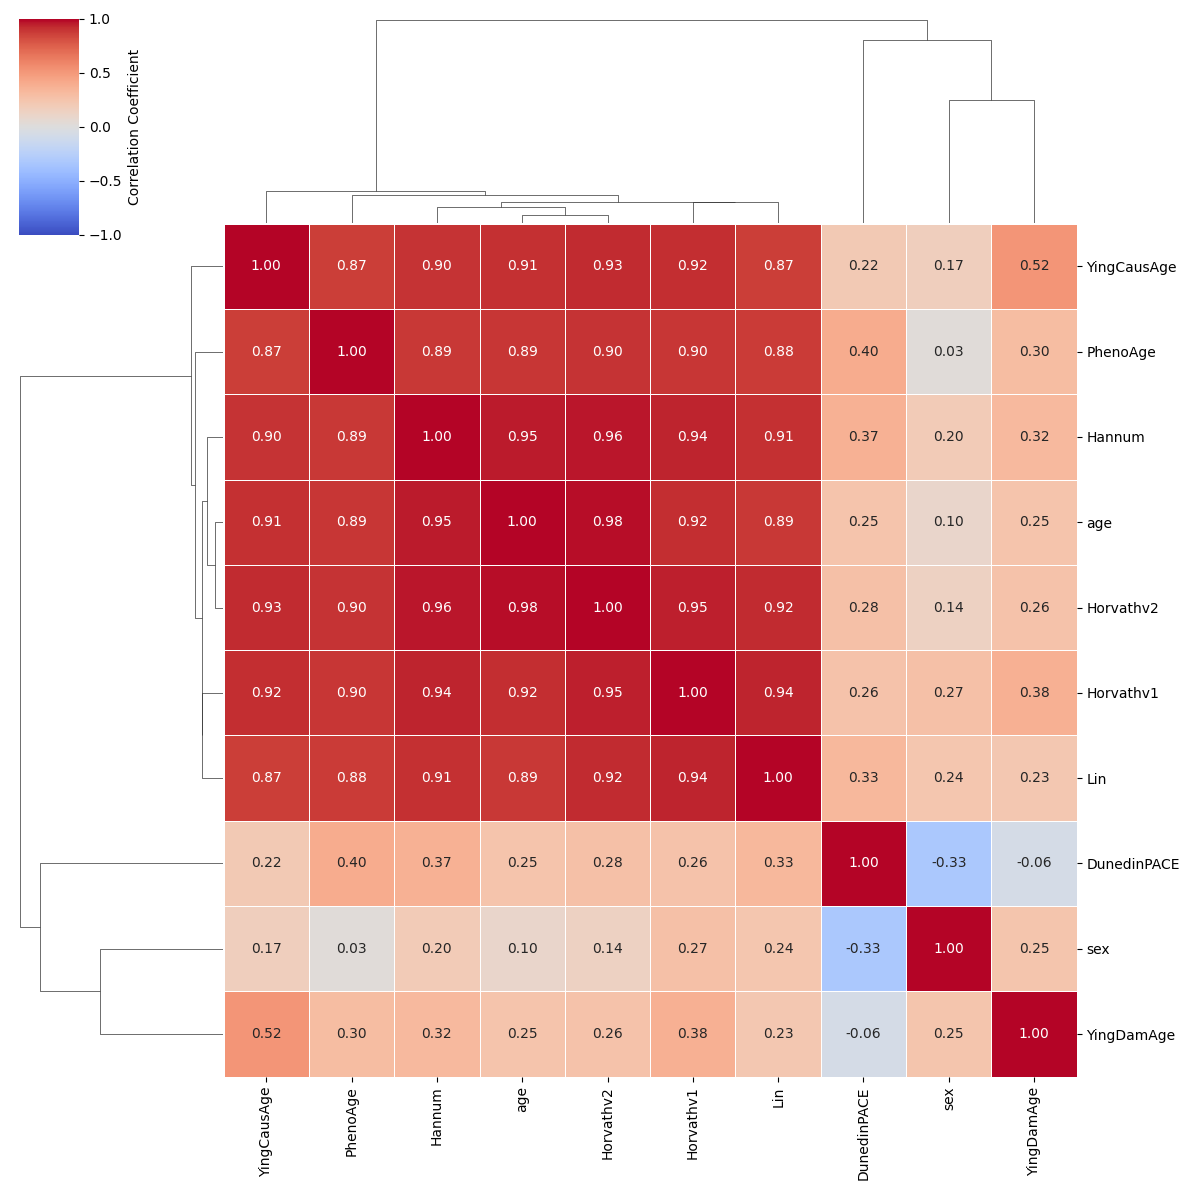

<Figure size 640x480 with 0 Axes>


Correlation matrix for GSE41169


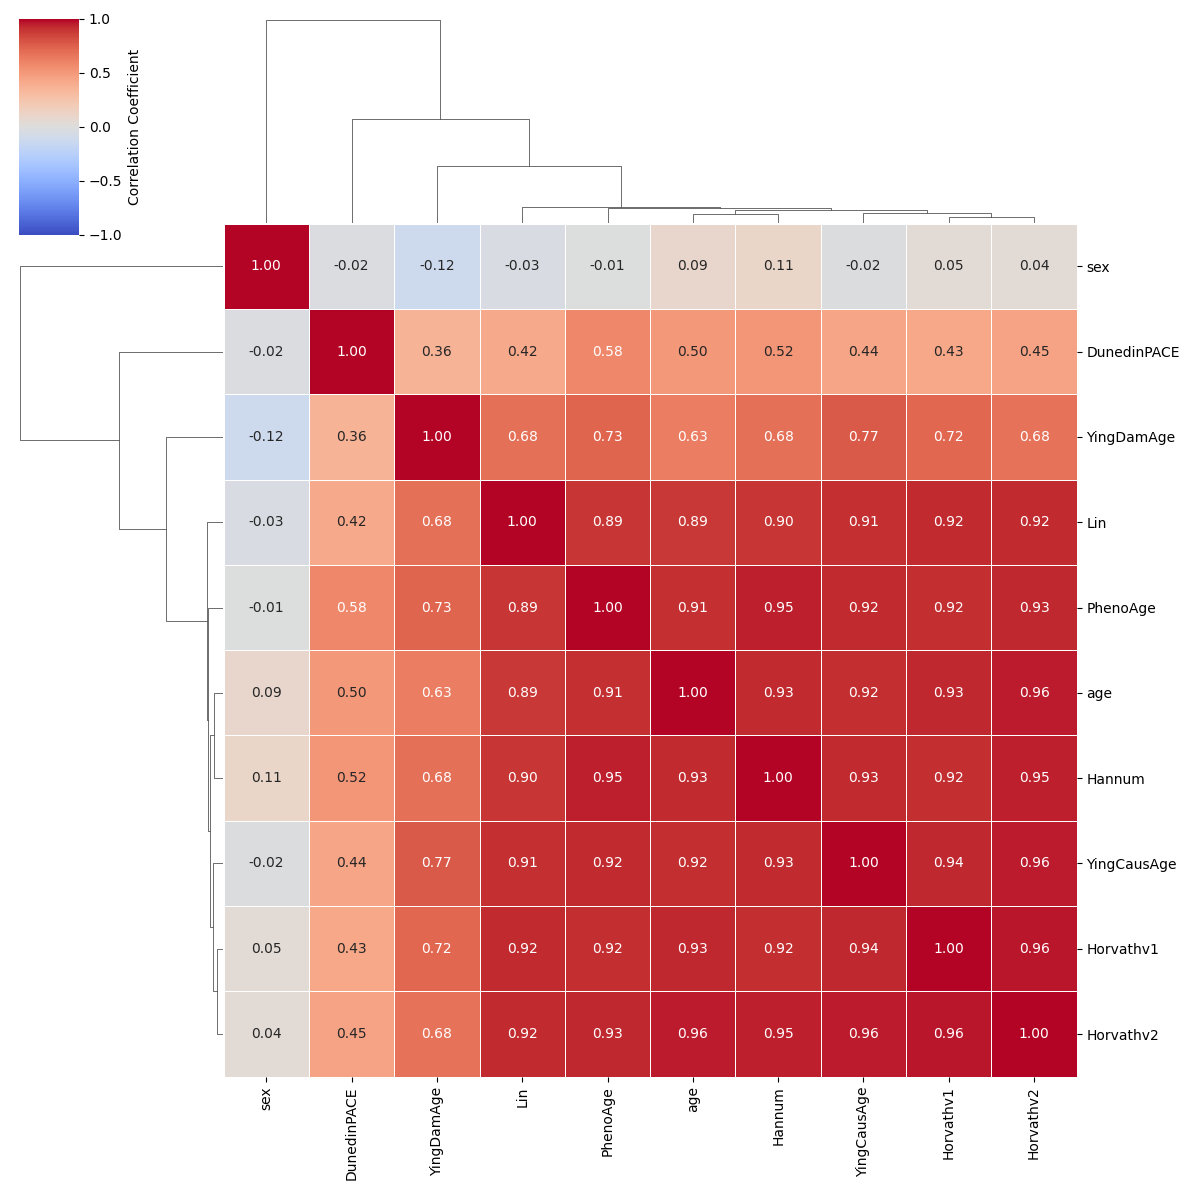

<Figure size 640x480 with 0 Axes>

In [ ]:
# --------------------------------------------------
# Correlation matrices for each dataset
# --------------------------------------------------
for ds_id, ds in datasets.items():
    print(f"\nCorrelation matrix for {ds_id}")
    plot_clock_correlation_matrix(
        models=[models[m] for m in model_names],
        data=ds
    )
    plt.suptitle(f"Correlation Matrix Across Aging Clocks — {ds_id}", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


**Explanation**
* This section generates a **correlation matrix** showing how strongly the predictions from different aging clocks agree with one another within each dataset.
* High correlation suggests that two clocks capture similar aging-related methylation patterns, while lower correlation may indicate that they measure distinct dimensions of aging.
* Separate plots are produced for each dataset so that inter-clock relationships can be compared across cohorts.

## 7. Visualize Clock Deviations Across Samples


Deviation heatmap for GSE120307


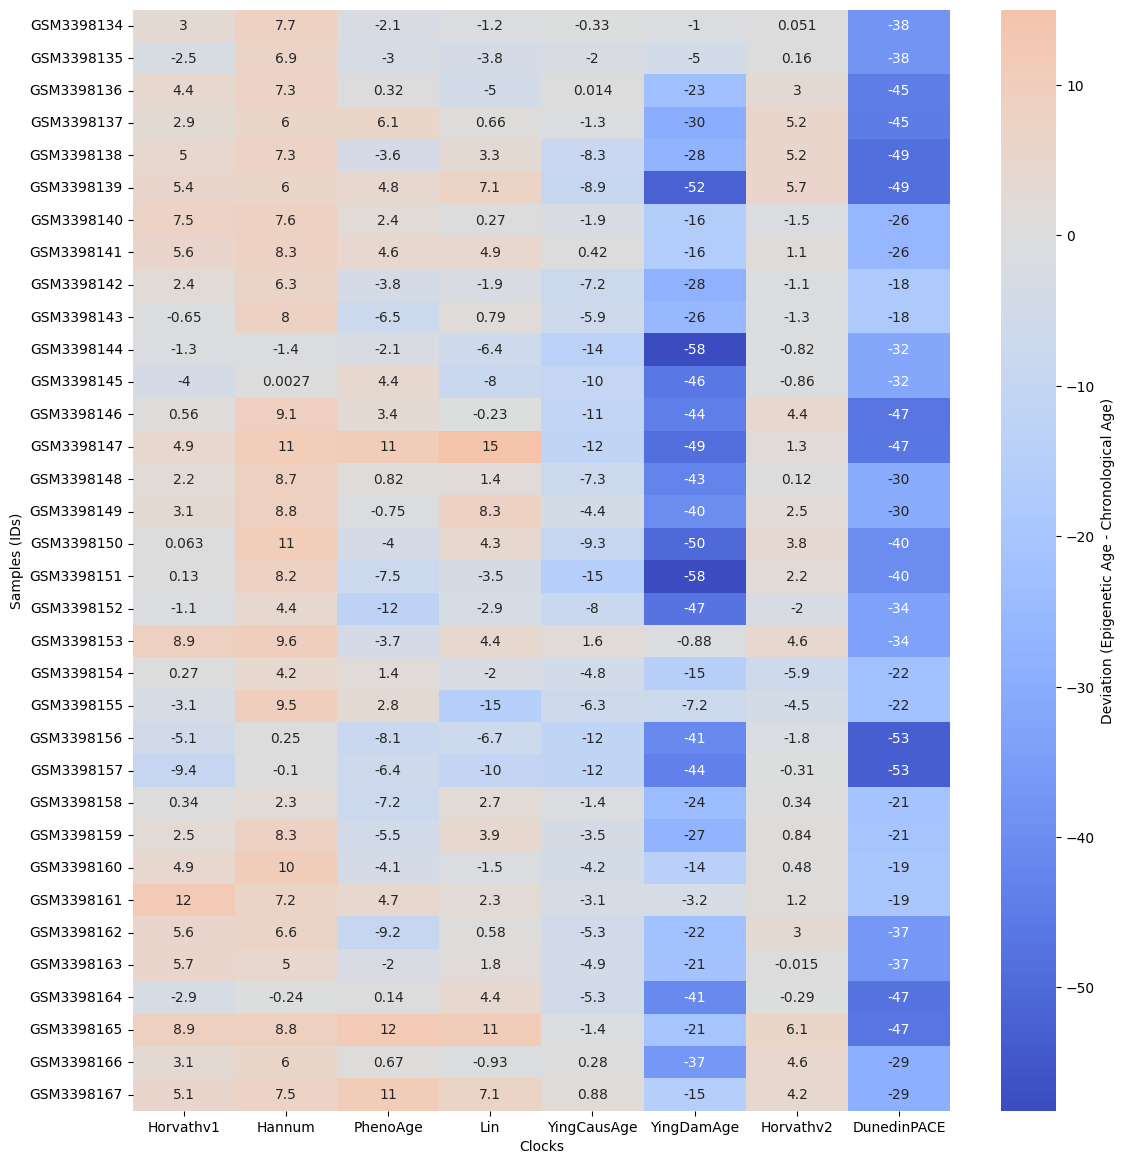

<Figure size 640x480 with 0 Axes>


Deviation heatmap for GSE41169


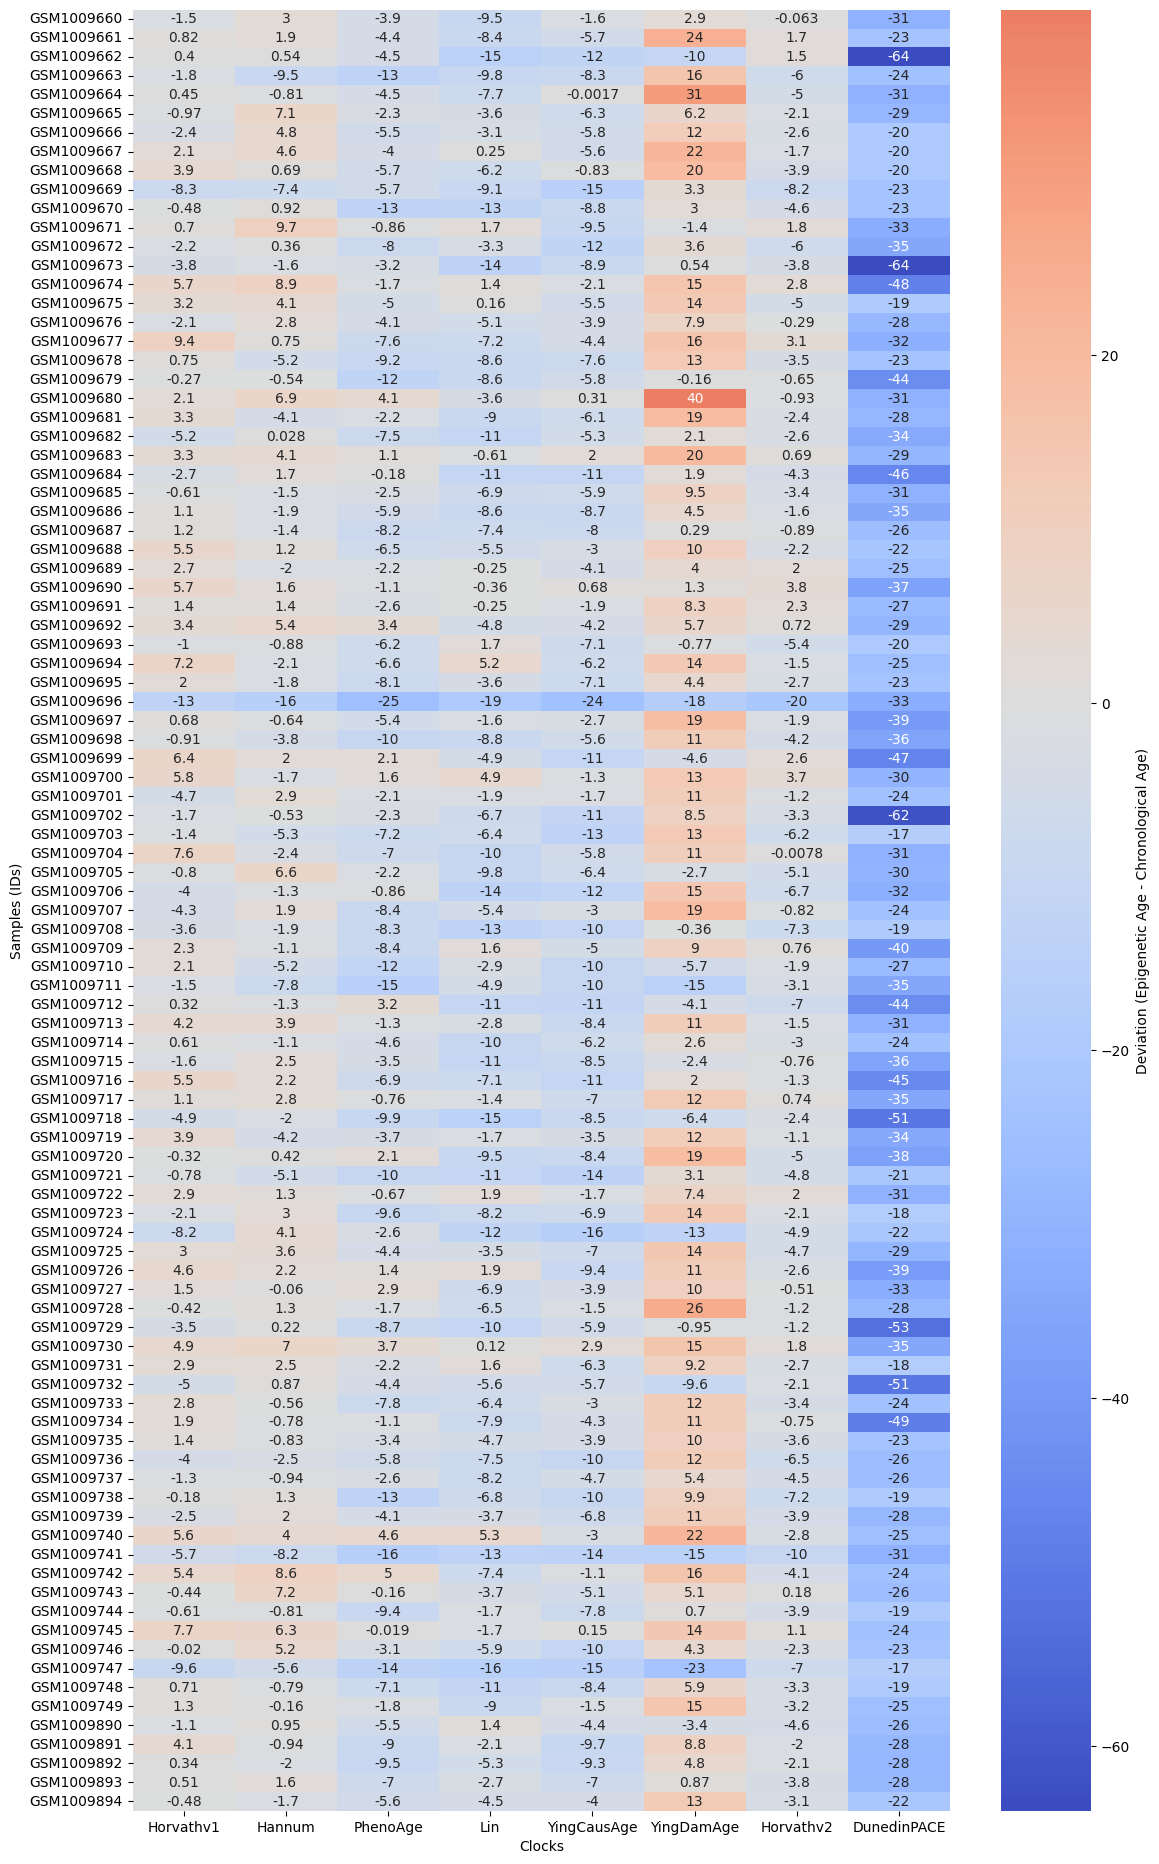

<Figure size 640x480 with 0 Axes>

In [ ]:
# --------------------------------------------------
# Deviation heatmaps for each dataset
# --------------------------------------------------
for ds_id, ds in datasets.items():
    print(f"\nDeviation heatmap for {ds_id}")
    plot_clock_deviation_heatmap(
        models=[models[m] for m in model_names],
        data=ds
    )
    plt.suptitle(f"Clock Deviation Heatmap — {ds_id}", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


**Explanation**
* This block visualizes a **heatmap of age deviations** across individuals and clocks, helping identify where predictions are consistently above or below chronological age.
* It is useful for spotting **sample-specific patterns**, such as individuals appearing biologically older or younger across multiple clocks.
* Comparing heatmaps across datasets can reveal whether deviation structure is stable or cohort-dependent.

## 8. Plot Predicted Age vs Chronological Age


Predicted age vs chronological age for GSE120307


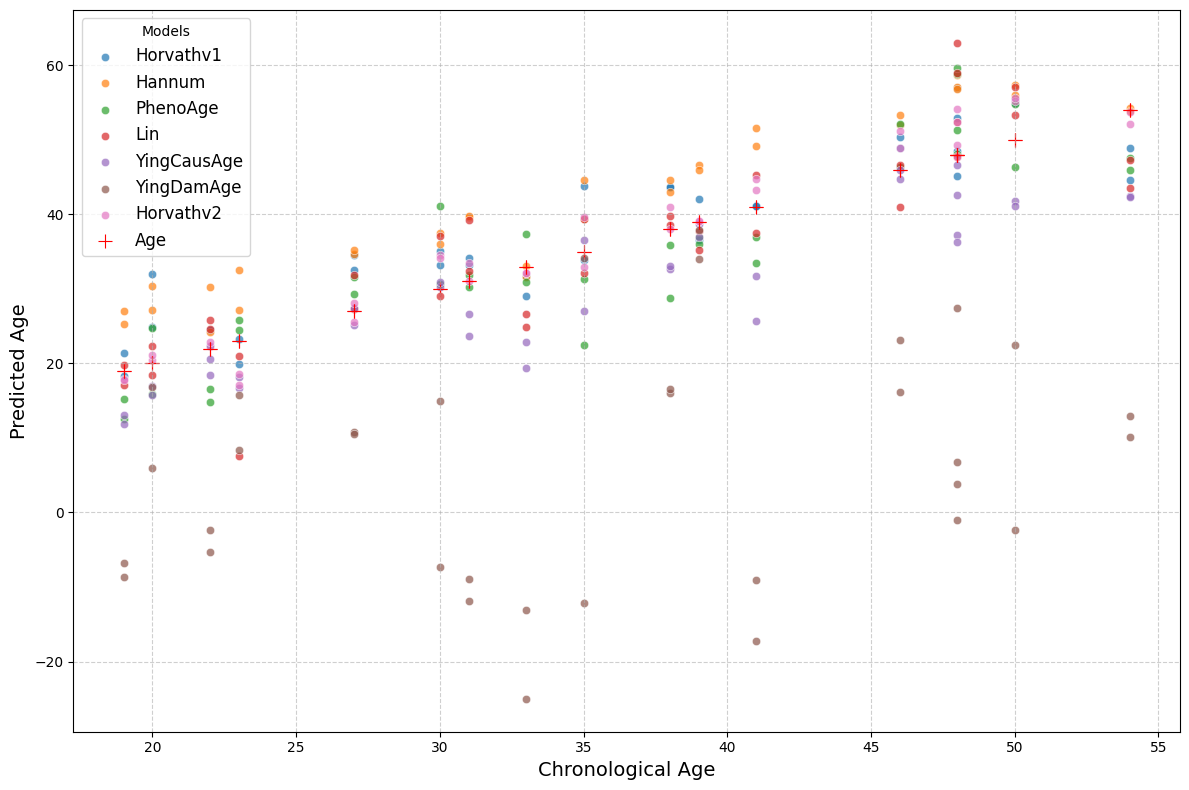

<Figure size 640x480 with 0 Axes>


Predicted age vs chronological age for GSE41169


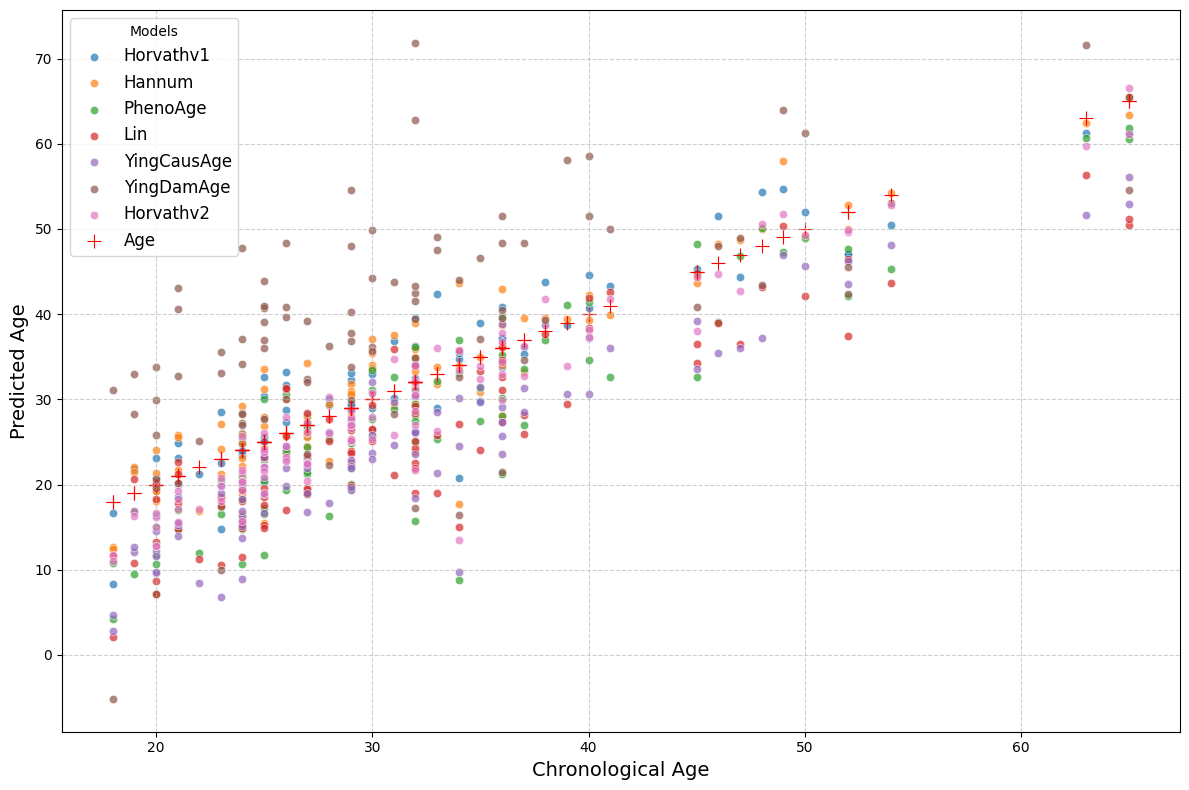

<Figure size 640x480 with 0 Axes>

In [ ]:
# --------------------------------------------------
# Prediction vs chronological age plots
# DunedinPACE is excluded here because it is not an age-in-years predictor
# --------------------------------------------------
age_prediction_models = [m for m in model_names if m != "DunedinPACE"]

for ds_id, ds in datasets.items():
    print(f"\nPredicted age vs chronological age for {ds_id}")
    plot_age_prediction(
        models=[models[m] for m in age_prediction_models],
        data=ds
    )
    plt.suptitle(f"Predicted Age vs Chronological Age — {ds_id}", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


**Explanation**
* This section plots each model’s predicted age against actual chronological age for both datasets.
* DunedinPACE is excluded because it estimates pace of aging, not age in years, so it is not directly comparable on this plot.
* These plots provide a quick visual check of model calibration, spread, and alignment with the ideal age-prediction trend.

## 9. Compute Numerical Benchmark Metrics

In [ ]:
# --------------------------------------------------
# Compute predictions manually for numerical comparison
# DunedinPACE is excluded from age-error metrics
# --------------------------------------------------
results = []

for ds_id, ds in datasets.items():
    actual_age = ds.metadata["age"]

    for model_name in age_prediction_models:
        try:
            pred_df = models[model_name].predict(ds)
            pred = pred_df.iloc[:, 0]

            common_ids = pred.index.intersection(actual_age.index)
            y_true = actual_age.loc[common_ids]
            y_pred = pred.loc[common_ids]

            mae = np.mean(np.abs(y_pred - y_true))
            rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
            corr = y_pred.corr(y_true)

            results.append({
                "Dataset": ds_id,
                "Model": model_name,
                "MAE": round(mae, 2),
                "RMSE": round(rmse, 2),
                "Pearson_r": round(corr, 3)
            })

        except Exception as e:
            print(f"Skipping {model_name} on {ds_id}: {e}")

results_df = pd.DataFrame(results)
display(results_df)


,Dataset,Model,MAE,RMSE,Pearson_r
0,GSE120307,Horvathv1,3.96,4.89,0.919
1,GSE120307,Hannum,6.45,7.15,0.953
2,GSE120307,PhenoAge,4.77,5.82,0.892
3,GSE120307,Lin,4.53,5.96,0.888
4,GSE120307,YingCausAge,5.68,7.07,0.912
5,GSE120307,YingDamAge,29.24,33.61,0.250
6,GSE120307,Horvathv2,2.37,3.07,0.978
7,GSE41169,Horvathv1,2.95,3.89,0.935
8,GSE41169,Hannum,3.05,4.12,0.929
9,GSE41169,PhenoAge,5.57,6.96,0.912


**Explanation**
* This block computes quantitative benchmark metrics for each age-prediction model on each dataset.
* The metrics include **MAE** for average prediction error, **RMSE** for error magnitude with stronger penalty for large mistakes, and **Pearson correlation** for agreement with chronological age.
* These values allow direct performance comparison beyond visual inspection of the plots.

## 10. Create Pivot Tables for Easier Model Comparison

In [ ]:
# --------------------------------------------------
# Pivot tables for easier comparison
# --------------------------------------------------
mae_table = results_df.pivot(index="Model", columns="Dataset", values="MAE")
corr_table = results_df.pivot(index="Model", columns="Dataset", values="Pearson_r")

print("Mean Absolute Error by model and dataset")
display(mae_table)

print("Correlation with chronological age by model and dataset")
display(corr_table)


Mean Absolute Error by model and dataset


Dataset,GSE120307,GSE41169
Model,,
Hannum,6.45,3.05
Horvathv1,3.96,2.95
Horvathv2,2.37,3.24
Lin,4.53,6.36
PhenoAge,4.77,5.57
YingCausAge,5.68,6.76
YingDamAge,29.24,10.21


Correlation with chronological age by model and dataset


Dataset,GSE120307,GSE41169
Model,,
Hannum,0.953,0.929
Horvathv1,0.919,0.935
Horvathv2,0.978,0.958
Lin,0.888,0.885
PhenoAge,0.892,0.912
YingCausAge,0.912,0.916
YingDamAge,0.250,0.627


**Explanation**
* This block reshapes the benchmark results into **side-by-side comparison tables** across datasets.
* The MAE table highlights which clocks are more accurate in absolute age prediction, while the correlation table highlights which clocks best preserve age ranking across individuals.
* These pivoted summaries make it much easier to identify consistently strong or weak models.

## 11. Visualize Benchmark Results with Bar Charts

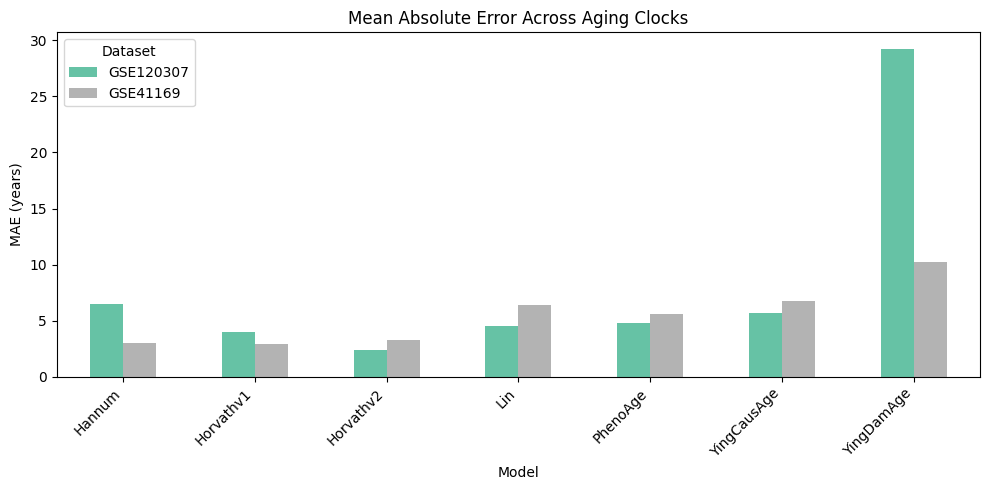

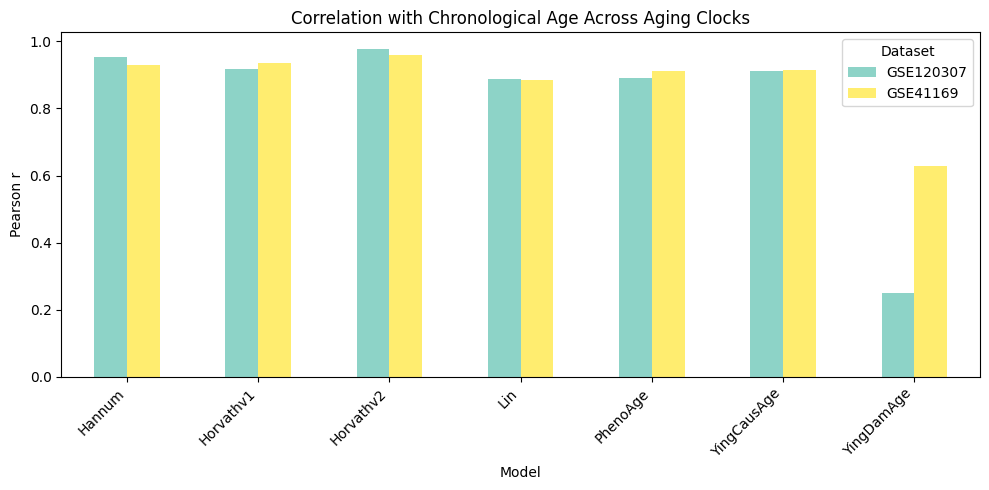

In [ ]:
# --------------------------------------------------
# Benchmark plots
# --------------------------------------------------
mae_table.plot(kind="bar", figsize=(10, 5), colormap="Set2")
plt.title("Mean Absolute Error Across Aging Clocks")
plt.ylabel("MAE (years)")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

corr_table.plot(kind="bar", figsize=(10, 5), colormap="Set3")
plt.title("Correlation with Chronological Age Across Aging Clocks")
plt.ylabel("Pearson r")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Explanation**
* This final visualization block presents the benchmark metrics as bar charts, making cross-model comparison more intuitive.
* The **MAE plot** highlights lower-is-better models, while the correlation plot highlights higher-is-better models.
* These charts provide a quick summary of clock performance across both datasets and help communicate findings clearly in reports or presentations.